In [99]:
# import features
import pandas as pd
# acitvity entropy
df_entropy = pd.read_csv('../output/data_cleaned/activity_entropy_rates.csv')
print(df_entropy.shape)

# early warning scores (physiological)
df_EWS = pd.read_csv('../output/data_cleaned/Mian_warning_score.csv')
df_EWS.columns = ['patient_id', 'date', 'early_warning_score']


# sleep quality
df_sleep_quality = pd.read_csv('../output/sleep_score/sleep_quality_score_by_duration.csv')
df_sleep_quality = df_sleep_quality.drop(columns= ['sum', 'mean','scaled_sleep_quality_sum']).copy()
df_sleep_quality.columns = ['patient_id', 'date', 'sleep_quality_score']

# agitation
df_agitation = pd.read_csv('../output/data_cleaned/agitation_daily_counts.csv')

# uti
df_uti = pd.read_csv('../output/data_cleaned/uti_daily.csv')

merged_df = df_entropy
# merge dataframes
for df in [df_EWS, df_sleep_quality, df_agitation, df_uti]:
    print(df.shape)
    merged_df = pd.merge(merged_df, df, on=['patient_id', 'date'], how='outer')
    
# only consider the patients without NA in the following analysis (as the analysis itself will be individualized anyway)
analysis_df = merged_df.dropna(subset=['sleep_quality_score']).dropna(subset=['early_warning_score']).dropna(subset=['entropy_rate']).copy()
analysis_df =  analysis_df.fillna(0)


# remove the first 10 days (anomaly detection was not applied during these days)
analysis_df["date"] = pd.to_datetime(analysis_df["date"])
print(analysis_df.shape)

df_filtered = (
    analysis_df.sort_values(["patient_id", "date"])
      .groupby("patient_id", group_keys=False)
      .apply(lambda x: x.iloc[10:])
)

df_filtered['date'] = pd.to_datetime(df_filtered.date).dt.strftime('%m-%d').astype(str).values

df_filtered
# df_filtered.patient_id.unique()

(2722, 3)
(2160, 3)
(800, 3)
(115, 3)
(265, 3)
(660, 7)


,patient_id,date,entropy_rate,early_warning_score,sleep_quality_score,agitation_counts,uti_happen
274,16f4b,05-22,0.593706,0.0,1.625769,0.0,0.0
282,16f4b,05-30,0.685258,0.0,1.298563,0.0,0.0
287,16f4b,06-04,0.658693,0.0,-0.010261,0.0,0.0
324,1fbe4,05-05,0.681941,1.0,0.513269,0.0,0.0
325,1fbe4,05-06,0.668119,0.0,2.607387,0.0,0.0
...,...,...,...,...,...,...,...
2694,f220c,06-06,0.620975,0.0,-2.627908,0.0,0.0
2696,f220c,06-08,0.527123,0.0,2.607387,0.0,0.0
2706,f220c,06-19,0.527442,0.0,2.607387,0.0,0.0
2709,f220c,06-22,0.608841,0.0,2.607387,0.0,0.0


In [101]:
import pandas as pd

ForestIsolation_sliding_01 = pd.read_csv('../output/Anomaly_delirium/forest_isolation_sliding_0.1contamination/forest_isolation_anomaly_data.csv').reset_index(drop = True)

ForestIsolation_sliding_01['anomaly'] = 1
ForestIsolation_sliding_01

,date,patient_id,anomaly
0,05-07,1fbe4,1
1,05-08,1fbe4,1
2,05-09,1fbe4,1
3,05-11,1fbe4,1
4,05-26,1fbe4,1
...,...,...,...
66,06-11,c8574,1
67,04-22,ec812,1
68,04-26,ec812,1
69,05-21,ec812,1


In [103]:
data_merge  = pd.merge(df_filtered, ForestIsolation_sliding_01, on=["patient_id", "date"], how="left")
print(data_merge.anomaly.sum())
data_merge

71.0


,patient_id,date,entropy_rate,early_warning_score,sleep_quality_score,agitation_counts,uti_happen,anomaly
0,16f4b,05-22,0.593706,0.0,1.625769,0.0,0.0,NaN
1,16f4b,05-30,0.685258,0.0,1.298563,0.0,0.0,NaN
2,16f4b,06-04,0.658693,0.0,-0.010261,0.0,0.0,NaN
3,1fbe4,05-05,0.681941,1.0,0.513269,0.0,0.0,NaN
4,1fbe4,05-06,0.668119,0.0,2.607387,0.0,0.0,NaN
...,...,...,...,...,...,...,...,...
498,f220c,06-06,0.620975,0.0,-2.627908,0.0,0.0,1.0
499,f220c,06-08,0.527123,0.0,2.607387,0.0,0.0,NaN
500,f220c,06-19,0.527442,0.0,2.607387,0.0,0.0,NaN
501,f220c,06-22,0.608841,0.0,2.607387,0.0,0.0,NaN


In [104]:
data_anomaly = data_merge.query('anomaly == 1').reset_index(drop = True).drop(["patient_id", "date", "anomaly"], axis=1)
data_non_anomaly = data_merge.query('anomaly != 1').reset_index(drop = True).drop(["patient_id", "date", "anomaly"], axis=1)
data_anomaly

,entropy_rate,early_warning_score,sleep_quality_score,agitation_counts,uti_happen
0,0.681583,1.0,-0.664672,0.0,1.0
1,0.643295,0.0,-0.533790,0.0,0.0
2,0.665559,1.0,-1.506059,0.0,1.0
3,0.609564,1.0,-0.272025,0.0,1.0
4,0.670373,0.0,-1.580849,0.0,0.0
...,...,...,...,...,...
66,0.596592,0.0,-1.755359,0.0,1.0
67,0.595762,1.0,-0.991878,0.0,0.0
68,0.690293,1.0,-0.991878,0.0,1.0
69,0.724717,0.0,-0.758160,0.0,0.0


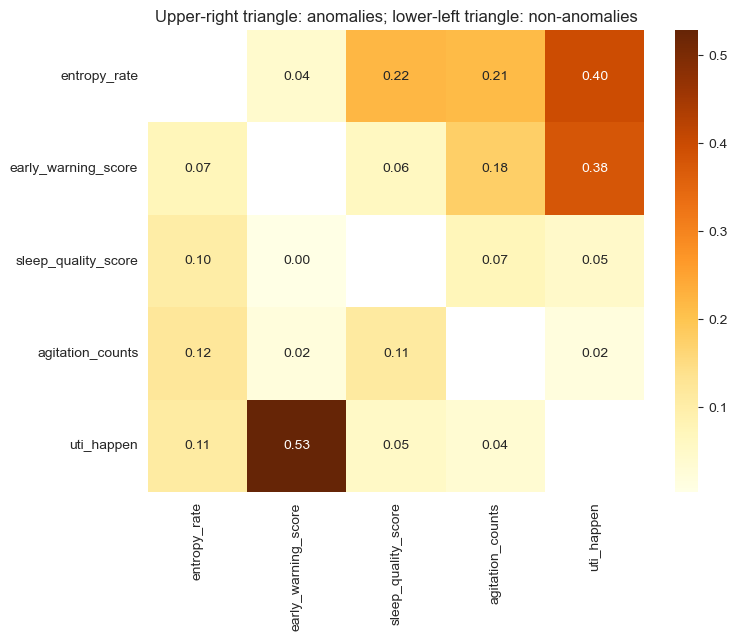

In [108]:
# calculate corr
method_use = "pearson"
# method_use = "kendall"
# method_use = "spearman"
correlation_matrix_anomaly = data_anomaly.corr(method=method_use)
correlation_matrix_NONanomaly = data_non_anomaly.corr(method=method_use)


##### prepare matrix for plotting
import numpy as np
# Step 1: Create a square matrix filled with NaN values or zeros
n = len(correlation_matrix_anomaly)  # Assuming both matrices have the same shape
combined_corr_matrix = np.zeros((n, n))
# lower (tril)
combined_corr_matrix[np.tril_indices(n, 0)] = correlation_matrix_NONanomaly.values[np.tril_indices(n, 0)]
#upper (triu)
combined_corr_matrix[np.triu_indices(n, 0)] = correlation_matrix_anomaly.values[np.triu_indices(n, 0)]


combined_corr_matrix_df = pd.DataFrame(combined_corr_matrix, columns=correlation_matrix_anomaly.columns, index=correlation_matrix_anomaly.columns)

np.fill_diagonal(combined_corr_matrix, np.nan)
combined_corr_matrix_df = abs(combined_corr_matrix_df)


# Visualize the result (if needed)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(combined_corr_matrix_df, annot=True, cmap="YlOrBr", fmt=".2f")
plt.title("Upper-right triangle: anomalies; lower-left triangle: non-anomalies")


plt.savefig('../output/Anomaly_delirium/correlation_patterns/corr_compare.png', dpi=300, bbox_inches="tight")

plt.show()